## 1. Business Understanding

**Problem Statement:**
We want to understand how users move through the e-commerce journey and identify where they drop off before completing a purchase.

**Funnel Definition**
1. View → User views a product
2. Cart → User adds product to cart
3. Purchase → User completes purchase

**Business Objective**

- Increase conversion from View to Purchase
- Identify where users drop off
- Provide actionable recommendations to improve conversion

**Key Questions**

1. How many users reach each stage of the funnel?
2. What is the conversion rate between each stage?
3. Where is the highest drop-off?
4. Do different categories or price ranges behave differently?
5. When (time/day) do users convert the most?

**Success Metrics**

- View → Cart Conversion Rate
- Cart → Purchase Conversion Rate
- Overall Conversion Rate (View → Purchase)

**Analyst Role**

As a data analyst, my goal is to:
- Track user journey through the funnel
- Identify drop-off points
- Provide data-driven recommendations to improve conversion

# 2. Data Understanding

In [ ]:
pip install pandas numpy matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
import pandas as pd

df = pd.read_csv('../data/ecommerce_events_nov2019.csv')
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [3]:
df.shape

(67501979, 9)

In [4]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='str')

**Dataset Columns Understanding**

- event_time → timestamp of event
- event_type → type of action (view, cart, purchase)
- user_id → unique user identifier
- product_id → product identifier
- category_id → product category
- category_code → category name
- brand → product brand
- price → product price

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67501979 entries, 0 to 67501978
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 4.5 GB


- event_time is currently in string format and needs conversion to datetime for time-based analysis

In [6]:
df['event_type'].value_counts()

event_type
view        63556110
cart         3028930
purchase      916939
Name: count, dtype: int64

- Significant drop-off occurs at the View → Cart stage
- Conversion from Cart → Purchase is relatively stronger

In [7]:
df.isnull().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    21898171
brand             9224078
price                   0
user_id                 0
user_session           10
dtype: int64

**Data Quality Observations**

- category_code and brand have significant missing values
- These fields are not critical for initial funnel analysis
- user_session has negligible missing values (can be ignored)
- Core columns (event_type, user_id, event_time) are complete

In [8]:
df['user_id'].nunique()

3696117

In [9]:
df.groupby('user_id').size().sort_values(ascending=False).head()

user_id
568778435    22929
569335945    14810
568818636     6171
512475445     6111
512365995     6042
dtype: int64

**User Behavior Observations**

- Users generate multiple events (not one row per user)
- Some users have extremely high activity, indicating repeated interactions or possible noise
- Funnel analysis should be performed at user level, not event level

In [10]:
df['event_time'].head()

0    2019-11-01 00:00:00 UTC
1    2019-11-01 00:00:00 UTC
2    2019-11-01 00:00:01 UTC
3    2019-11-01 00:00:01 UTC
4    2019-11-01 00:00:01 UTC
Name: event_time, dtype: str

## Key Observations

1. The dataset is event-based, meaning each user can generate multiple actions (view, cart, purchase) over time rather than a single record.

2. There is a significant imbalance in event types, with a very high number of views compared to carts and purchases, indicating major drop-off in early funnel stages.

3. Users exhibit repeated interactions, with some users generating thousands of events, suggesting either high engagement or potential noise in the data.

4. Funnel analysis must be performed at the user level (unique users), not at the event level, to avoid inflated and misleading conversion rates.

5. Core fields required for funnel analysis (event_type, user_id, event_time) are complete and reliable.

6. category_code and brand contain a large number of missing values, but they are not critical for initial funnel analysis.

7. event_time is currently stored as a string and will need to be converted to datetime for time-based analysis.

# 3. Data Preparation

In [11]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [12]:
df['event_time'].dtype

datetime64[us, UTC]

In [13]:
df = df.sort_values(by=['user_id', 'event_time'])

In [14]:
df = df[['user_id', 'event_time', 'event_type', 'product_id', 'price']]

In [15]:
df.isnull().sum()

user_id       0
event_time    0
event_type    0
product_id    0
price         0
dtype: int64

In [20]:
df = df.sample(frac=0.2, random_state=42)
df = df.sort_values(by=['user_id', 'event_time'])

In [23]:
df = df.reset_index(drop=True)

In [24]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13500396 entries, 0 to 13500395
Data columns (total 5 columns):
 #   Column      Dtype              
---  ------      -----              
 0   user_id     int64              
 1   event_time  datetime64[us, UTC]
 2   event_type  str                
 3   product_id  int64              
 4   price       float64            
dtypes: datetime64[us, UTC](1), float64(1), int64(2), str(1)
memory usage: 515.0 MB


**Data Preparation Summary**

- Converted `event_time` from string to datetime format to support time-based analysis
- Reduced dataset size using 20% random sampling to improve performance and make analysis manageable
- Sorted data by `user_id` and `event_time` to preserve the correct sequence of user actions
- Selected only the core columns required for funnel analysis: `user_id`, `event_time`, `event_type`, `product_id`, and `price`
- Verified that there are no missing values in the key fields used for funnel construction
- Reset the index after sampling and sorting to keep the dataframe clean and organized

**Key Decisions**

- Excluded `category_code` and `brand` from the initial analysis because they had many missing values and were not required for the first version of the funnel
- Chose to analyze behavior at the user level rather than the event level to avoid inflated conversion counts
- Used a sampled dataset to balance analytical depth with system performance

## 4. Funnel Construction

In [25]:
user_funnel = df.groupby('user_id')['event_type'].agg(list).reset_index()

In [26]:
user_funnel['view'] = user_funnel['event_type'].apply(lambda x: 1 if 'view' in x else 0)
user_funnel['cart'] = user_funnel['event_type'].apply(lambda x: 1 if 'cart' in x else 0)
user_funnel['purchase'] = user_funnel['event_type'].apply(lambda x: 1 if 'purchase' in x else 0)

In [27]:
total_users = user_funnel['user_id'].nunique()

view_users = user_funnel[user_funnel['view'] == 1]['user_id'].nunique()
cart_users = user_funnel[user_funnel['cart'] == 1]['user_id'].nunique()
purchase_users = user_funnel[user_funnel['purchase'] == 1]['user_id'].nunique()

print(total_users, view_users, cart_users, purchase_users)

2391475 2351749 357969 137988


In [28]:
view_to_cart = cart_users / view_users
cart_to_purchase = purchase_users / cart_users
overall_conversion = purchase_users / view_users

print(view_to_cart, cart_to_purchase, overall_conversion)

0.15221394800210397 0.38547471987797827 0.058674628967632175


In [29]:
funnel_df = pd.DataFrame({
    'Stage': ['View', 'Cart', 'Purchase'],
    'Users': [view_users, cart_users, purchase_users]
})

funnel_df['Conversion'] = funnel_df['Users'] / funnel_df['Users'].shift(1)
funnel_df.loc[0, 'Conversion'] = 1

funnel_df

,Stage,Users,Conversion
0,View,2351749,1.000000
1,Cart,357969,0.152214
2,Purchase,137988,0.385475


**Limitation of Basic Funnel :**

The initial funnel was constructed based on whether a user performed an action at any point in time. However, this approach does not consider the order of events.

This can lead to inflated or misleading results, as users may be counted in later stages without actually following the correct journey (e.g., purchase without a prior cart event).

To address this, we refine the funnel by enforcing the correct sequence of actions.

In [30]:
def check_sequence(events):
    try:
        view_index = events.index('view')
        cart_index = events.index('cart')
        purchase_index = events.index('purchase')
        
        return view_index < cart_index < purchase_index
    except ValueError:
        return False

In [31]:
user_funnel['valid_sequence'] = user_funnel['event_type'].apply(check_sequence)

In [32]:
valid_users = user_funnel[user_funnel['valid_sequence'] == True]['user_id'].nunique()

valid_users

28310

In [33]:
def check_view(events):
    return 'view' in events

def check_view_cart(events):
    try:
        return events.index('view') < events.index('cart')
    except ValueError:
        return False

def check_full(events):
    try:
        return events.index('view') < events.index('cart') < events.index('purchase')
    except ValueError:
        return False

In [34]:
user_funnel['view_flag'] = user_funnel['event_type'].apply(check_view)
user_funnel['view_cart_flag'] = user_funnel['event_type'].apply(check_view_cart)
user_funnel['full_funnel_flag'] = user_funnel['event_type'].apply(check_full)

In [35]:
view_users_seq = user_funnel[user_funnel['view_flag'] == True]['user_id'].nunique()

view_cart_users = user_funnel[user_funnel['view_cart_flag'] == True]['user_id'].nunique()

full_users = user_funnel[user_funnel['full_funnel_flag'] == True]['user_id'].nunique()

print(view_users_seq, view_cart_users, full_users)

2351749 254666 28310


In [36]:
view_to_cart_seq = view_cart_users / view_users_seq
cart_to_purchase_seq = full_users / view_cart_users
overall_seq = full_users / view_users_seq

print(view_to_cart_seq, cart_to_purchase_seq, overall_seq)

0.10828791678023462 0.1111652124743782 0.012037849277282566


 **Refined Funnel (Sequence-Based)**

- The funnel was reconstructed by ensuring users followed the correct order: View → Cart → Purchase
- Only users with valid behavioral sequences were considered in the final counts

**Key Insights**

- The number of users completing the full funnel dropped significantly after applying sequence validation
- This indicates that the initial funnel slightly overestimated user progression
- The refined funnel provides a more realistic and reliable view of user behavior

**Business Interpretation**

- The major drop still occurs at the View → Cart stage, confirming it as the most critical point for optimization
- Improving early-stage engagement (product pages, pricing, UX) can significantly increase overall conversion

**Limitation of Analysis**

- The dataset is limited to a single month (November 2019)
- Some users may have started their journey in a previous period (e.g., viewed or added to cart earlier) and completed purchase in this month
- These users may be excluded from the sequence-based funnel due to incomplete observable behavior
- As a result, the refined funnel prioritizes accuracy over completeness

# 5. SEGMENTATION

In [37]:
df['price_segment'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])

In [38]:
user_price = df.groupby('user_id')['price_segment'].agg(lambda x: x.mode()[0]).reset_index()

user_funnel = user_funnel.merge(user_price, on='user_id', how='left')

In [39]:
segmented = user_funnel.groupby('price_segment').agg({
    'view_flag': 'sum',
    'view_cart_flag': 'sum',
    'full_funnel_flag': 'sum'
}).reset_index()

segmented

,price_segment,view_flag,view_cart_flag,full_funnel_flag
0,Low,849898,88661,9450
1,Medium,761203,86666,9880
2,High,740648,79339,8980


In [40]:
segmented['view_to_cart'] = segmented['view_cart_flag'] / segmented['view_flag']
segmented['cart_to_purchase'] = segmented['full_funnel_flag'] / segmented['view_cart_flag']
segmented['overall'] = segmented['full_funnel_flag'] / segmented['view_flag']

segmented

,price_segment,view_flag,view_cart_flag,full_funnel_flag,view_to_cart,cart_to_purchase,overall
0,Low,849898,88661,9450,0.104320,0.106586,0.011119
1,Medium,761203,86666,9880,0.113854,0.114001,0.012979
2,High,740648,79339,8980,0.107121,0.113185,0.012125


**Segmentation Analysis (Price-Based)**

- Users were segmented into Low, Medium, and High price groups based on product prices
- Each user was assigned a dominant price segment based on their most frequent interactions
- Funnel conversion rates were calculated separately for each segment

**Key Findings**

- Medium-priced products show the highest conversion rates across all stages of the funnel
- Low-priced products attract higher browsing but slightly lower purchase intent
- High-priced products show moderate engagement but potential hesitation in conversion

**Business Interpretation**

- Medium-priced products represent a strong opportunity for maximizing conversions
- Low-priced products may benefit from upselling strategies or bundling
- High-priced products may require trust-building elements such as reviews, discounts, or financing options

**Conclusion**

- Price impacts user behavior, but differences are moderate
- Other factors such as product quality, brand, and user experience may also significantly influence conversion

# 6. Recommendations

**Business Recommendations**

Based on the funnel and segmentation analysis, the following actions are recommended:

**1. Improve View → Cart Conversion (Primary Focus)**

- Introduce urgency mechanisms such as limited-time offers and countdown timers, especially for low-priced products with high traffic but low conversion
- Highlight discounts and promotional messaging to encourage immediate action

**2. Optimize Medium Price Segment (Quick Wins)**

- Emphasize product value through comparison features and clear benefit communication
- Introduce bundling strategies (e.g., buy 2 get 1 free) to increase perceived value

**3. Improve High Price Conversion (Reduce Hesitation)**

- Strengthen trust through brand visibility, customer reviews, and ratings
- Provide reassurance through return policies, guarantees, and secure payment messaging

**4. Personalization & Targeting (Future Scope)**

- Use user behavior data to personalize offers and recommendations
- Trigger notifications or reminders for users who previously interacted but did not convert

# 7. Time-Based Analysis

In [41]:
df['hour'] = df['event_time'].dt.hour
df['day'] = df['event_time'].dt.day_name()

In [42]:
hourly = df.groupby('hour')['event_type'].value_counts().unstack().fillna(0)

hourly

event_type,cart,purchase,view
hour,,,
0,3284,561,86441
1,6970,835,160838
2,13929,2138,319079
3,23893,5321,450995
4,31424,8904,572967
5,35539,10718,642166
6,36950,11723,662041
7,37655,11865,667770
8,37751,13015,686129


<Axes: xlabel='hour'>

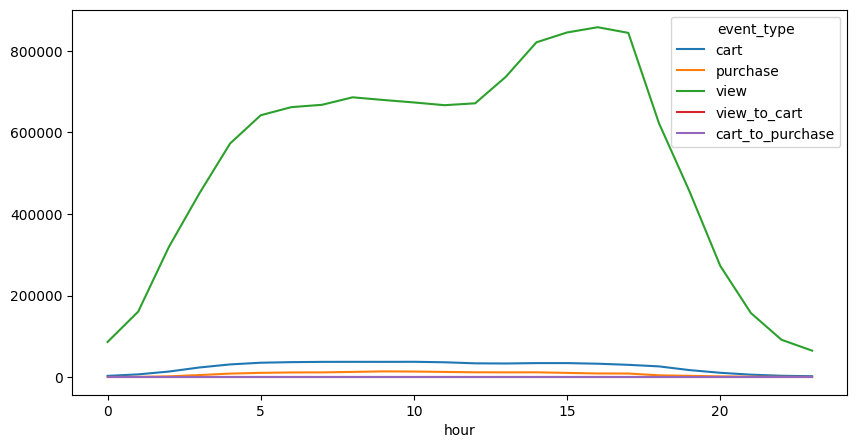

In [48]:
hourly.plot(kind='line', figsize=(10,5))

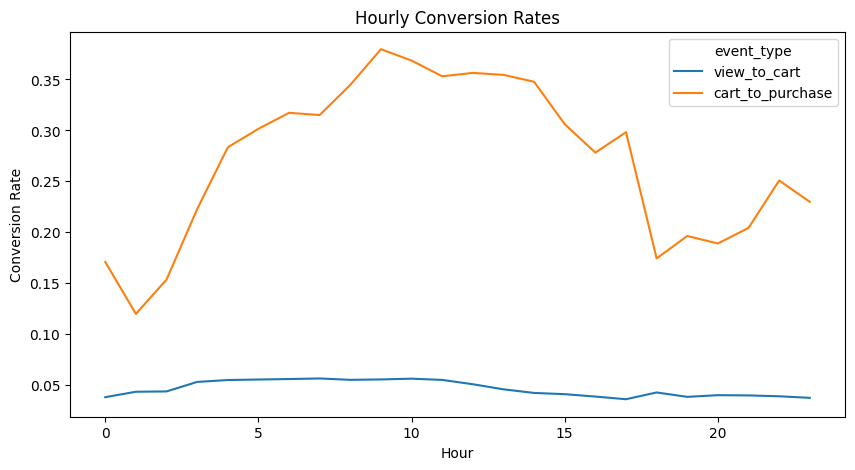

In [49]:
hourly['view_to_cart'] = hourly['cart'] / hourly['view']
hourly['cart_to_purchase'] = hourly['purchase'] / hourly['cart']

hourly[['view_to_cart', 'cart_to_purchase']].plot(figsize=(10,5))

plt.title("Hourly Conversion Rates")
plt.xlabel("Hour")
plt.ylabel("Conversion Rate")
plt.show()

In [43]:
daily = df.groupby('day')['event_type'].value_counts().unstack().fillna(0)

daily

event_type,cart,purchase,view
day,,,
Friday,148965,20905,2427577
Monday,50189,21248,1411878
Saturday,129172,32623,2491110
Sunday,117676,50859,2129045
Thursday,67463,19432,1552522
Tuesday,46707,19455,1351162
Wednesday,46945,19566,1345897


In [44]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = daily.reindex(order)

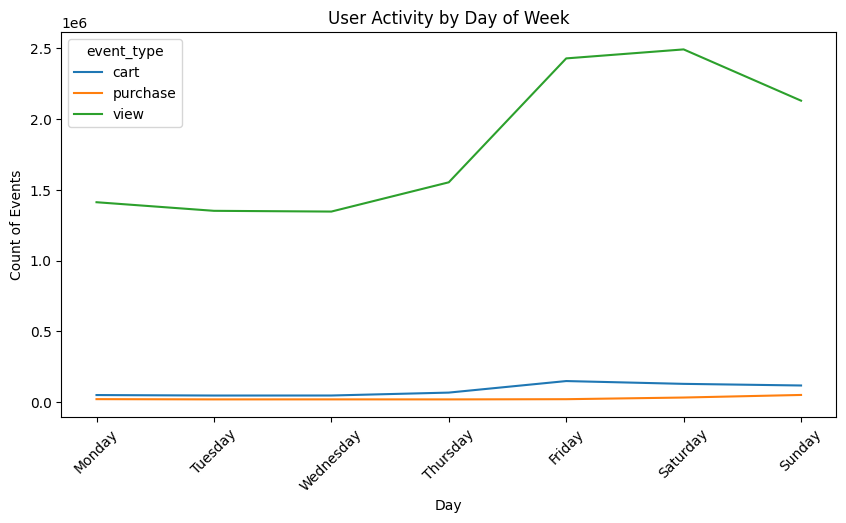

In [46]:
import matplotlib.pyplot as plt

daily.plot(kind='line', figsize=(10,5))

plt.title("User Activity by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count of Events")
plt.xticks(rotation=45)

plt.show()

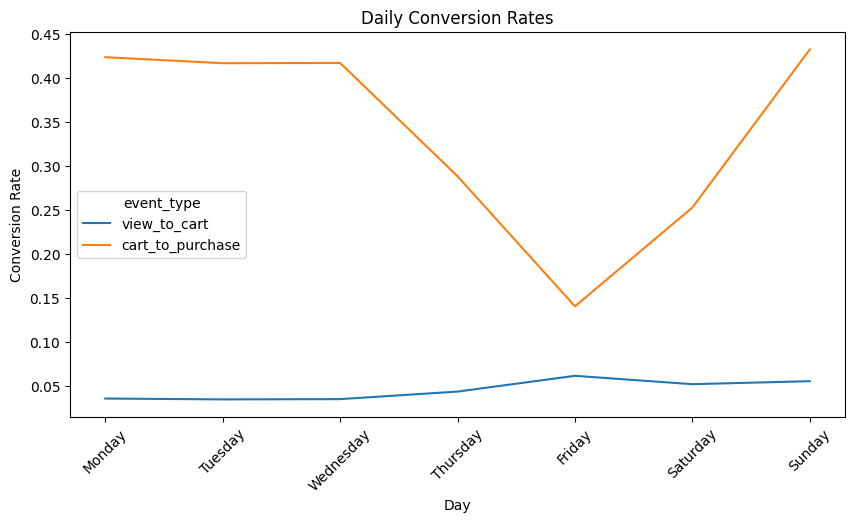

In [50]:
daily['view_to_cart'] = daily['cart'] / daily['view']
daily['cart_to_purchase'] = daily['purchase'] / daily['cart']

daily[['view_to_cart', 'cart_to_purchase']].plot(figsize=(10,5))

plt.title("Daily Conversion Rates")
plt.xlabel("Day")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.show()

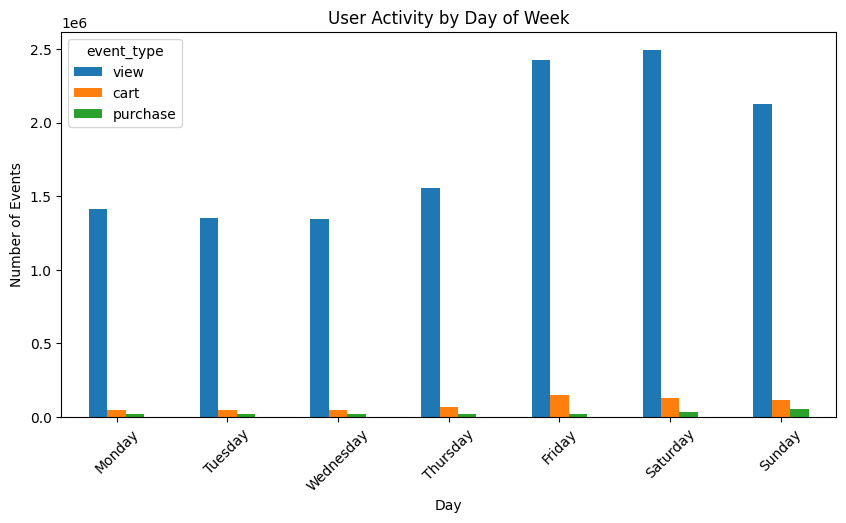

In [55]:
daily[['view', 'cart', 'purchase']].plot(kind='bar', figsize=(10,5))

plt.title("User Activity by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)

plt.show()

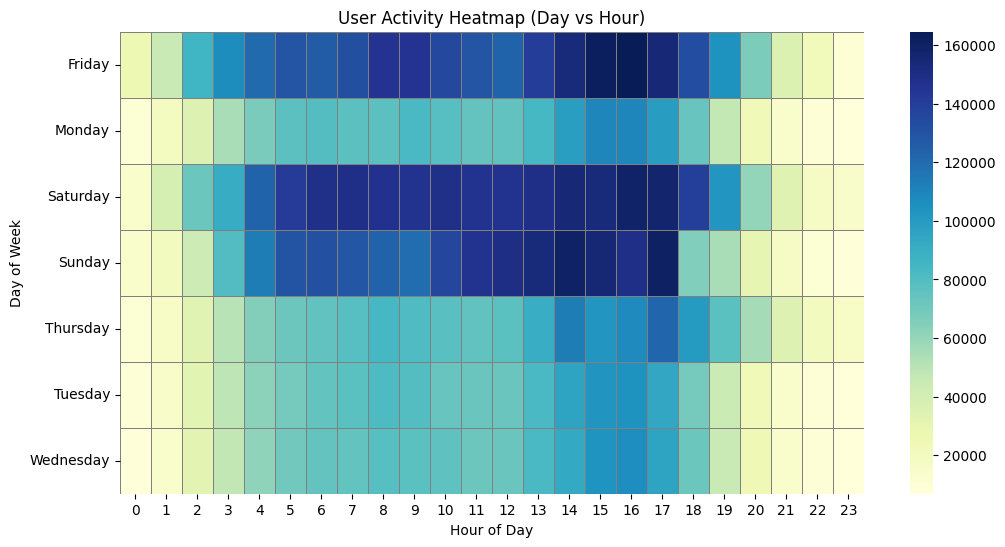

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',   # better contrast than 'Blues'
    linewidths=0.5,  # separation between cells
    linecolor='gray'
)

plt.title("User Activity Heatmap (Day vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

**Heatmap Analysis (User Activity Patterns)**

- User activity is highest between ~12 PM and 5 PM across most days  
- Engagement peaks on Friday and Saturday during afternoon hours  
- Activity drops significantly after ~8 PM  

**Business Interpretation**

- Schedule promotions during afternoon hours for maximum visibility  
- Leverage weekends for higher engagement  
- Avoid late-night campaigns due to low user activity  

# Time-Based Analysis

- Analyzed user activity patterns across hours of the day and days of the week
- Observed trends in views, carts, and purchases over time

**Key Insights**

- User activity peaks during afternoon to early evening hours (approximately 2 PM – 5 PM)
- Activity drops significantly during late-night hours
- Engagement increases toward the end of the week, with Friday and Saturday showing the highest activity levels
- Weekdays (Monday–Wednesday) show relatively lower engagement

**Conversion Behavior**

- Conversion rates vary across time, not just activity levels
- High activity periods do not always correspond to highest conversion rates

**Business Interpretation**

- Promotions and notifications should be scheduled during peak activity hours to maximize visibility
- High-conversion time windows should be prioritized for targeted campaigns
- Weekend periods offer strong opportunities for driving sales due to increased user engagement

## 8. Final Summary

- The largest drop-off occurs at the View → Cart stage, making it the most critical area for optimization
- Only a small percentage of users complete the full funnel when considering correct event sequence, indicating that earlier estimates were inflated
- Medium-priced products show the highest conversion, while low-priced products offer the greatest opportunity due to higher traffic
- User activity peaks during afternoon hours and weekends, but conversion varies across time

## Final Recommendation

- Focus on improving early-stage engagement (View → Cart) using urgency and value-driven strategies
- Leverage medium-priced products for quick conversion improvements
- Target high-activity and high-conversion time windows for marketing campaigns